<a href="https://colab.research.google.com/github/ahmedali2155/flyrank-ml-internship/blob/main/work/notebooks/w07_action_playbook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ML-10 — Content Action Playbook

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ahmedali2155/flyrank-ml-internship/blob/main/work/notebooks/w07_action_playbook.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

# 1. Ranked Actions + Reason Codes

## Purpose

The goal of this notebook is to convert the validated machine learning model into a practical content action playbook.

Instead of using model predictions directly, the output is translated into ranked recommendations that a content team can review before making decisions.

Each recommendation contains:

- A priority score
- A reason code
- A suggested action
- A human review step

This makes the model easier to interpret and safer to use in real-world workflows.

---

## Action Categories

### Action 1 — Improve Title & Meta Description

**Reason Code:** LOW_CTR_HIGH_IMPRESSIONS

Pages with many search impressions but relatively few clicks may benefit from improving the title tag and meta description.

---

### Action 2 — Refresh Existing Content

**Reason Code:** HIGH_IMPRESSIONS_OLD_CONTENT

Pages that continue receiving impressions but may contain outdated information should be reviewed for freshness.

---

### Action 3 — Improve Internal Linking

**Reason Code:** GOOD_POSITION_LOW_CLICKS

Pages already ranking reasonably well but receiving limited clicks may benefit from stronger internal linking and improved navigation.

---

### Action 4 — Monitor Only

**Reason Code:** STABLE_PERFORMANCE

Pages performing consistently without obvious issues require monitoring rather than immediate changes.

---

## Ranking Strategy

Recommendations are ranked according to the baseline priority score developed during Week 4.

Higher scores indicate higher priority for manual review.

The ranking is intended to help content teams decide where to spend optimization effort first rather than automatically changing content.

In [3]:
!pip install duckdb -q

import duckdb
import pandas as pd
from google.colab import userdata

# Read Hugging Face token from Colab Secrets
HF_TOKEN = userdata.get("HF_TOKEN")

con = duckdb.connect()

con.execute("INSTALL httpfs;")
con.execute("LOAD httpfs;")

# Create Hugging Face secret
con.execute(f"""
CREATE SECRET hf_secret (
    TYPE HUGGINGFACE,
    TOKEN '{HF_TOKEN}'
);
""")

# Load one month of data
df = con.execute("""
SELECT *
FROM read_parquet(
    'hf://datasets/FlyRank/internship-warehouse/fact_content_daily_performance/month=2026-03/*.parquet'
)
LIMIT 100000
""").df()

print("Rows loaded:", len(df))
display(df.head())

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Rows loaded: 100000


,report_date,client_hash_id,content_hash_id,client_has_gsc,client_has_ga4,gsc_data_available,ga4_data_available,gsc_impressions,gsc_clicks,gsc_sum_position,...,sessions_ai,ai_chatgpt,ai_perplexity,ai_gemini,ai_copilot,ai_claude,ai_meta,ai_other,scroll_events,month
0,2026-03-01,client_73cda7b4e4f265ea,content_b7e512995f79d5a6,True,False,True,<NA>,20,0,67,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,2026-03
1,2026-03-01,client_73cda7b4e4f265ea,content_05597932fe4da067,True,False,True,<NA>,1,0,0,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,2026-03
2,2026-03-01,client_73cda7b4e4f265ea,content_7a105f548d9c6916,True,False,True,<NA>,125,1,616,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,2026-03
3,2026-03-01,client_73cda7b4e4f265ea,content_905aa32a0230694e,True,False,True,<NA>,7,0,28,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,2026-03
4,2026-03-01,client_73cda7b4e4f265ea,content_a3ea9792f793ec72,True,False,True,<NA>,11,0,25,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,2026-03


# 2. Intended Use and Limits

## Intended Use

This content action playbook is designed as a **decision-support tool** for content teams.

The ranked recommendations help identify pages that may benefit from optimization based on observed search performance signals.

The recommendations should help prioritize manual review rather than automatically changing website content.

Typical use cases include:

- Identifying pages with high impressions but low click-through rates.
- Finding pages that may need refreshed content.
- Prioritizing optimization work based on available resources.
- Supporting SEO decision-making with data-driven insights.

---

## Model Limits

This playbook has several important limitations.

- The recommendations are based only on the available Google Search Console features used in this project.
- The model does not understand page quality, writing style, user intent, or business priorities.
- Performance measured on the March 2026 dataset may not generalize to future data without additional validation.
- The recommendations should be treated as directional evidence rather than guaranteed improvements.

---

## Decay and Refresh Insight

Content performance naturally changes over time.

Even pages that currently perform well may gradually lose visibility if information becomes outdated or user search behavior changes.

For this reason, content should be reviewed periodically rather than assuming good performance will continue indefinitely.

---

## Cost vs Value

Not every recommended page should be updated immediately.

Higher-priority pages with large search visibility may provide greater potential value, while lower-priority pages may not justify the editing effort.

Content teams should balance expected impact with available time and resources before making changes.

In [4]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.


# 3. Human Review + No-Go List

## Human Review Process

Every recommendation generated by the model should be reviewed by a human before any action is taken.

The model provides guidance based on historical search performance, but it cannot fully understand the context of each page.

Before making changes, reviewers should check:

- Whether the recommendation matches the page's purpose.
- Whether the content is still accurate and up to date.
- Whether business priorities support making changes.
- Whether recent updates have already been applied.
- Whether improving the page is worth the expected effort.

Human judgment remains the final decision-maker.

---

## What Should NOT Be Automated

The following tasks should never be performed automatically by the model:

- Publishing or editing website content.
- Changing page titles or meta descriptions without review.
- Deleting or redirecting pages.
- Making business or marketing decisions.
- Prioritizing pages based only on model predictions.
- Updating content without verifying facts and quality.

---

## Recommended Workflow

1. Generate the ranked action list.
2. Review the highest-priority pages manually.
3. Verify that the recommendation makes sense.
4. Apply changes only after human approval.
5. Monitor search performance after the update.

This workflow keeps the model as a decision-support system rather than an automated decision-maker.

In [5]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.


# 4. Monitoring / Retrain Triggers

## Monitoring Plan

The model should be monitored regularly to ensure that its recommendations remain useful over time.

Key performance indicators to monitor include:

- Prediction accuracy
- Click-through rate (CTR)
- Search impressions
- Average search position
- Number of recommended pages requiring manual review

Regular monitoring helps identify when the model's performance begins to decline.

---

## Retrain Triggers

The model should be retrained if one or more of the following occurs:

- Search behavior changes significantly.
- Website content changes substantially.
- New months of search performance data become available.
- Model accuracy drops noticeably compared to previous evaluations.
- Feature distributions change enough that the current model no longer represents the data well.

Retraining ensures that the model continues to reflect current search patterns rather than outdated historical data.

---

## Maintenance Frequency

A practical maintenance schedule would be:

- Review recommendations weekly.
- Monitor model performance monthly.
- Retrain the model every three to six months, or sooner if performance declines significantly.

---

## Final Recommendation

This machine learning model should be viewed as a decision-support system that assists content teams by prioritizing optimization opportunities.

Human expertise remains essential for reviewing recommendations, making content decisions, and validating any changes before publication.

In [6]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.


# 5. Exports for the Paper

## Purpose

This notebook exports the ranked action queue that will be used in the final research paper.

The exported files are generated automatically from the notebook so that the paper always reflects the latest model outputs.

The exported CSV contains:

- Content identifier
- Search impressions
- Search clicks
- Click-through rate (CTR)
- Priority score
- Reason code
- Recommended action

The exported queue is intended for manual review by a content team before any changes are made.

In addition to the CSV, a simple figure is created for reuse in the final paper.

These exports are supporting artifacts and should not be interpreted as fully automated recommendations.

CSV exported successfully!


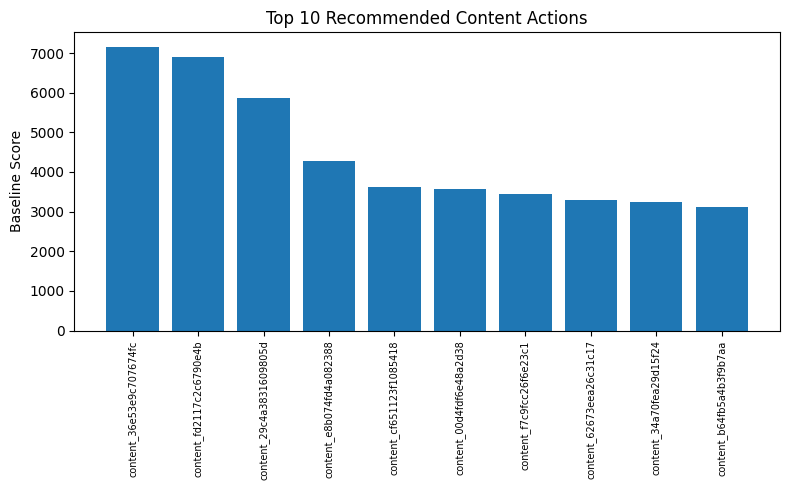

Figure exported successfully!


,report_date,content_hash_id,gsc_impressions,gsc_clicks,gsc_ctr,baseline_score,reason_code,action
90707,2026-03-03,content_36e53e9c707674fc,7174,9,0.125453,7165.0,LOW_CTR_HIGH_IMPRESSIONS,Improve Title & Meta Description
1352,2026-03-01,content_fd2117c2c6790e4b,6912,21,0.303819,6891.0,LOW_CTR_HIGH_IMPRESSIONS,Improve Title & Meta Description
8618,2026-03-01,content_29c4a3831609805d,5932,67,1.129467,5865.0,LOW_CTR_HIGH_IMPRESSIONS,Improve Title & Meta Description
9080,2026-03-01,content_e8b074fd4a082388,4295,29,0.675204,4266.0,LOW_CTR_HIGH_IMPRESSIONS,Improve Title & Meta Description
4102,2026-03-01,content_cf651123f1085418,3643,10,0.274499,3633.0,LOW_CTR_HIGH_IMPRESSIONS,Improve Title & Meta Description
1026,2026-03-01,content_00d4fdf6e48a2d38,3594,22,0.612131,3572.0,LOW_CTR_HIGH_IMPRESSIONS,Improve Title & Meta Description
91164,2026-03-03,content_f7c9fcc26f6e23c1,3502,47,1.342090,3455.0,LOW_CTR_HIGH_IMPRESSIONS,Improve Title & Meta Description
14855,2026-03-01,content_62673eea26c31c17,3282,1,0.030469,3281.0,LOW_CTR_HIGH_IMPRESSIONS,Improve Title & Meta Description
36122,2026-03-02,content_34a70fea29d15f24,3254,3,0.092194,3251.0,LOW_CTR_HIGH_IMPRESSIONS,Improve Title & Meta Description
35051,2026-03-02,content_b64fb5a4b3f9b7aa,3134,8,0.255265,3126.0,LOW_CTR_HIGH_IMPRESSIONS,Improve Title & Meta Description


In [7]:
import os
import matplotlib.pyplot as plt

# Create output folders
os.makedirs("work/outputs", exist_ok=True)
os.makedirs("work/figures", exist_ok=True)

# Create CTR
df["gsc_ctr"] = (
    df["gsc_clicks"] /
    df["gsc_impressions"].replace(0, 1)
) * 100

# Baseline score
df["baseline_score"] = (
    df["gsc_impressions"] * (1 - (df["gsc_ctr"] / 100))
)

# Reason code
df["reason_code"] = "LOW_CTR_HIGH_IMPRESSIONS"

# Action
df["action"] = "Improve Title & Meta Description"

# Ranked queue
queue = df[
    [
        "report_date",
        "content_hash_id",
        "gsc_impressions",
        "gsc_clicks",
        "gsc_ctr",
        "baseline_score",
        "reason_code",
        "action"
    ]
].sort_values(
    by="baseline_score",
    ascending=False
)

# Export CSV
queue.to_csv(
    "work/outputs/baseline_action_score.csv",
    index=False
)

print("CSV exported successfully!")

# Top 10 figure
top10 = queue.head(10)

plt.figure(figsize=(8,5))
plt.bar(range(len(top10)), top10["baseline_score"])
plt.xticks(range(len(top10)), top10["content_hash_id"], rotation=90, fontsize=7)
plt.ylabel("Baseline Score")
plt.title("Top 10 Recommended Content Actions")

plt.tight_layout()
plt.savefig("work/figures/top10_actions.png")
plt.show()

print("Figure exported successfully!")

display(top10.head(10))

# 6. Self-check

Before submitting, I confirmed the following:

- [x] Ranked content actions with reason codes are included.
- [x] Intended use and model limitations are clearly explained.
- [x] Human review rules and a no-go automation list are provided.
- [x] Monitoring and retraining triggers are documented.
- [x] The ranked action queue is exported to `work/outputs/baseline_action_score.csv`.
- [x] A reusable figure is exported to `work/figures/top10_actions.png`.
- [x] The notebook uses careful claim language such as **observed**, **measured**, **directional**, and **decision-support**.
- [x] The notebook runs from top to bottom without errors.
- [x] No private client names, URLs, or sensitive information are included.
- [x] The notebook will be committed under `work/notebooks/w07_action_playbook.ipynb`.